# Lecture 6 — Building an Autodiff Framework

**CMU 10-414/714, Deep Learning Systems**
Companion notebook · Sangram Lembe

Lecture 5 gave the algorithm: define adjoints, walk the graph backwards, build the gradient as
new graph nodes. This notebook builds the data structures that make it a framework — a miniature
version of *needle*, in about 150 lines.

The central move is small and strange: **a tensor stops being an array and becomes an array that
remembers how it was produced.** Almost everything else follows from that, including a memory bug
that catches people in real PyTorch code.

By the end we train the same MLP as lecture 4, with no hand-derived gradients anywhere.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
np.random.seed(0)

## 1. `Value`: data plus provenance

A `Value` carries four fields. Only the first is what you would put in a matrix class:

| field | holds |
|---|---|
| `cached_data` | the actual numbers |
| `op` | the operation that produced this value |
| `inputs` | the `Value`s that operation consumed |
| `requires_grad` | whether gradients need to flow through here |

The other three exist so that the value **is** a node in a computational graph. For a leaf — one
the user made directly — `op` is `None` and `inputs` is empty, which is how the graph knows where
it ends.

Note also that `make_from_op` records the node but performs **no arithmetic**. The computation
happens in `realize_cached_data`, and whether that runs immediately is one flag: `LAZY_MODE`.

In [2]:
LAZY_MODE = False          # eager by default, as in PyTorch and in needle

class Value:
    """A node in a computational graph."""

    def _init(self, op, inputs, cached_data=None, requires_grad=None):
        if requires_grad is None:
            requires_grad = any(i.requires_grad for i in inputs)
        self.op            = op             # None for a leaf
        self.inputs        = inputs         # the operands, themselves Values
        self.cached_data   = cached_data    # the numbers, or None if not yet computed
        self.requires_grad = requires_grad
        self.grad          = None           # filled in by the backward pass

    def realize_cached_data(self):
        """Run the op if we have not already. This is where arithmetic happens."""
        if self.cached_data is None:
            self.cached_data = self.op.compute(
                *[i.realize_cached_data() for i in self.inputs])
        return self.cached_data

    def is_leaf(self):
        return self.op is None

In [3]:
class Tensor(Value):
    """A Value the user interacts with. Operators build graph nodes, not numbers."""

    def __init__(self, array, requires_grad=True):
        self._init(None, [], cached_data=np.array(array, dtype=np.float64),
                   requires_grad=requires_grad)

    @staticmethod
    def make_from_op(op, inputs):
        """Record the node. Compute now only if we are in eager mode."""
        t = Tensor.__new__(Tensor)
        t._init(op, inputs)
        if not LAZY_MODE:
            t.realize_cached_data()
        return t

    @staticmethod
    def make_const(data):
        """A leaf holding data, with no history. This is what detach returns."""
        t = Tensor.__new__(Tensor)
        t._init(None, [], cached_data=np.asarray(data, dtype=np.float64),
                requires_grad=False)
        return t

    @property
    def data(self):  return self.realize_cached_data()
    @property
    def shape(self): return self.data.shape

    def detach(self):
        """Same numbers, no graph. Severs the history."""
        return Tensor.make_const(self.data)

    def __repr__(self):
        origin = "leaf" if self.is_leaf() else type(self.op).__name__
        return f"Tensor(shape={self.shape}, from={origin})"

    # operator overloads - each one builds a node
    def __add__(self, o):     return add(self, o)   if isinstance(o, Tensor) else add_scalar(self, o)
    def __mul__(self, o):     return mul(self, o)   if isinstance(o, Tensor) else mul_scalar(self, o)
    def __sub__(self, o):     return self + (-o if isinstance(o, Tensor) else -o)
    def __neg__(self):        return mul_scalar(self, -1.0)
    def __truediv__(self, o): return div_scalar(self, o)
    def __pow__(self, s):     return power_scalar(self, s)
    def __matmul__(self, o):  return matmul(self, o)
    __radd__ = __add__
    __rmul__ = __mul__

## 2. `Op`: two methods, and a deliberate asymmetry

Every operation implements exactly two things:

- **`compute(*arrays)`** — given input *arrays*, return the output array. Pure numerics.
- **`gradient(out_grad, node)`** — given the output adjoint, return the partial adjoint for each
  input. Built from *graph nodes*.

That asymmetry is the whole design. `compute` works on arrays because the graph structure is
already recorded elsewhere. `gradient` works on nodes because **its output must itself be
differentiable** — which is what buys gradient-of-gradient.

Each `gradient` below is one line of lecture 5's chain rule, localised to a single operation.

In [4]:
class Op:
    def __call__(self, *args):
        return Tensor.make_from_op(self, list(args))

    def gradient_as_tuple(self, out_grad, node):
        """Always return a tuple, so the traversal can treat every op alike."""
        g = self.gradient(out_grad, node)
        return g if isinstance(g, tuple) else (g,)


class EWiseAdd(Op):
    def compute(self, a, b):          return a + b
    def gradient(self, out_grad, node):
        return out_grad, out_grad                       # d(a+b)/da = d(a+b)/db = 1

class AddScalar(Op):
    def __init__(self, s):            self.s = s
    def compute(self, a):             return a + self.s
    def gradient(self, out_grad, node): return out_grad

class EWiseMul(Op):
    def compute(self, a, b):          return a * b
    def gradient(self, out_grad, node):
        a, b = node.inputs
        return out_grad * b, out_grad * a               # product rule

class MulScalar(Op):
    def __init__(self, s):            self.s = s
    def compute(self, a):             return a * self.s
    def gradient(self, out_grad, node): return out_grad * self.s

class DivScalar(Op):
    def __init__(self, s):            self.s = s
    def compute(self, a):             return a / self.s
    def gradient(self, out_grad, node): return out_grad / self.s

class PowerScalar(Op):
    def __init__(self, s):            self.s = s
    def compute(self, a):             return a ** self.s
    def gradient(self, out_grad, node):
        a = node.inputs[0]
        return out_grad * (a ** (self.s - 1)) * self.s  # still graph nodes

class Exp(Op):
    def compute(self, a):             return np.exp(a)
    def gradient(self, out_grad, node): return out_grad * exp(node.inputs[0])

add        = lambda a, b: EWiseAdd()(a, b)
add_scalar = lambda a, s: AddScalar(s)(a)
mul        = lambda a, b: EWiseMul()(a, b)
mul_scalar = lambda a, s: MulScalar(s)(a)
div_scalar = lambda a, s: DivScalar(s)(a)
power_scalar = lambda a, s: PowerScalar(s)(a)
exp        = lambda a: Exp()(a)

### Shape-changing ops

Reductions and broadcasts need a little care: the gradient of a sum is a broadcast, and the
gradient of a broadcast is a sum. They are duals of each other, which is a good sanity check when
writing them.

In [5]:
class Reshape(Op):
    def __init__(self, shape):        self.shape = shape
    def compute(self, a):             return a.reshape(self.shape)
    def gradient(self, out_grad, node):
        return reshape(out_grad, node.inputs[0].shape)

class BroadcastTo(Op):
    def __init__(self, shape):        self.shape = shape
    def compute(self, a):             return np.broadcast_to(a, self.shape).copy()
    def gradient(self, out_grad, node):
        in_shape = node.inputs[0].shape
        pad = len(self.shape) - len(in_shape)
        # axes that were created, plus axes that were stretched from length 1
        axes = tuple(range(pad)) + tuple(
            pad + i for i, s in enumerate(in_shape)
            if s == 1 and self.shape[pad + i] != 1)
        g = summation(out_grad, axes) if axes else out_grad
        return reshape(g, in_shape)

class Summation(Op):
    def __init__(self, axes=None):    self.axes = axes
    def compute(self, a):             return a.sum(axis=self.axes)
    def gradient(self, out_grad, node):
        in_shape = node.inputs[0].shape
        if self.axes is None:
            keep = (1,) * len(in_shape)
        else:
            ax = self.axes if isinstance(self.axes, tuple) else (self.axes,)
            keep = tuple(1 if i in ax else s for i, s in enumerate(in_shape))
        return broadcast_to(reshape(out_grad, keep), in_shape)

class Transpose(Op):
    def compute(self, a):             return a.T
    def gradient(self, out_grad, node): return transpose(out_grad)

reshape      = lambda a, shape: Reshape(shape)(a)
broadcast_to = lambda a, shape: BroadcastTo(shape)(a)
summation    = lambda a, axes=None: Summation(axes)(a)
transpose    = lambda a: Transpose()(a)

### The two ops a network actually needs

`MatMul` is the linear layer, and its gradient is exactly the rule derived at the end of lecture
5: $\overline{X} = \overline{Z}W^{\mathsf{T}}$ and $\overline{W} = X^{\mathsf{T}}\overline{Z}$.

`LogSumExp` is the numerically stable half of cross-entropy. Its gradient is the softmax — and
notice it is *built from ops*, so the loss remains differentiable twice over.

In [6]:
class MatMul(Op):
    def compute(self, a, b):          return a @ b
    def gradient(self, out_grad, node):
        a, b = node.inputs
        return matmul(out_grad, transpose(b)), matmul(transpose(a), out_grad)

class ReLU(Op):
    def compute(self, a):             return np.maximum(0, a)
    def gradient(self, out_grad, node):
        # the mask is a constant: relu' is not itself differentiable
        mask = Tensor.make_const((node.inputs[0].data > 0).astype(np.float64))
        return out_grad * mask

class LogSumExp(Op):
    """log sum_j exp(z_j) along `axis`, computed stably."""
    def __init__(self, axis=1):       self.axis = axis
    def compute(self, a):
        mx = a.max(axis=self.axis, keepdims=True)
        return (np.log(np.exp(a - mx).sum(axis=self.axis, keepdims=True)) + mx
                ).squeeze(self.axis)
    def gradient(self, out_grad, node):
        z = node.inputs[0]
        keep = tuple(1 if i == self.axis else s for i, s in enumerate(z.shape))
        lse = reshape(node, keep)                        # reuse the forward value
        softmax = exp(z - broadcast_to(lse, z.shape))    # d(logsumexp)/dz
        return broadcast_to(reshape(out_grad, keep), z.shape) * softmax

matmul     = lambda a, b: MatMul()(a, b)
relu       = lambda a: ReLU()(a)
logsumexp  = lambda a, axis=1: LogSumExp(axis)(a)

## 3. The traversal

Now lecture 5's algorithm, unchanged. Two details carry the correctness:

- **Reverse topological order** guarantees that when a node is reached, every consumer has
  already deposited its partial adjoint — so the sum is complete. That is the multiple-pathway
  rule, enforced by ordering rather than bookkeeping.
- `node.grad` is assigned a **node**, so the gradient of the gradient is available by running the
  same function on the result.

In [7]:
def find_topo_sort(node_list):
    """Depth-first post-order: every node appears after all of its inputs."""
    visited, topo = set(), []
    def visit(n):
        if id(n) in visited:
            return
        visited.add(id(n))
        for i in n.inputs:
            visit(i)
        topo.append(n)
    for n in node_list:
        visit(n)
    return topo

def compute_gradient_of_variables(out_tensor, out_grad):
    """Reverse-mode AD. Sets .grad on every node in out_tensor's graph."""
    node_to_partials = {id(out_tensor): [out_grad]}      # lists of PARTIAL adjoints
    index = {id(out_tensor): out_tensor}

    for node in reversed(find_topo_sort([out_tensor])):
        if id(node) not in node_to_partials:
            continue                                     # not on a path to the output
        parts = node_to_partials[id(node)]
        node.grad = parts[0]
        for extra in parts[1:]:
            node.grad = node.grad + extra                # multiple pathways add
        if node.is_leaf():
            continue
        for inp, partial in zip(node.inputs,
                                node.op.gradient_as_tuple(node.grad, node)):
            node_to_partials.setdefault(id(inp), []).append(partial)
            index[id(inp)] = inp

def backward(t):
    """Seed the output adjoint with ones and run the backward pass."""
    compute_gradient_of_variables(t, Tensor.make_const(np.ones_like(t.data)))

Tensor.backward = backward

## 4. Does it work?

The first test is the one lecture 5 ended with: build the running example as a graph and check
the gradient against the analytic answer.

In [8]:
class Log(Op):
    def compute(self, a):             return np.log(a)
    def gradient(self, out_grad, node):
        return out_grad * (node.inputs[0] ** -1.0)

class Sin(Op):
    def compute(self, a):             return np.sin(a)
    def gradient(self, out_grad, node):
        return out_grad * cos(node.inputs[0])

class Cos(Op):
    def compute(self, a):             return np.cos(a)
    def gradient(self, out_grad, node):
        return out_grad * (-sin(node.inputs[0]))

log = lambda a: Log()(a); sin = lambda a: Sin()(a); cos = lambda a: Cos()(a)

x1, x2 = Tensor(2.0), Tensor(5.0)
y = log(x1) + x1 * x2 - sin(x2)          # the lecture 5 example
y.backward()

print("y            =", round(float(y.data), 6))
print("dy/dx1       =", round(float(x1.grad.data), 6), " analytic:", round(1/2 + 5, 6))
print("dy/dx2       =", round(float(x2.grad.data), 6), " analytic:", round(2 - np.cos(5), 6))
assert np.allclose(float(x1.grad.data), 1/2 + 5)
assert np.allclose(float(x2.grad.data), 2 - np.cos(5))
print("\nmatches the hand-derived trace from lecture 5")

y            = 11.652071
dy/dx1       = 5.5  analytic: 5.5
dy/dx2       = 1.716338  analytic: 1.716338

matches the hand-derived trace from lecture 5


## 5. The gradient is a graph, not a number

This is the payoff of `gradient` returning nodes. `x1.grad` is not a float — it is an expression
that can be differentiated again.

For $f(x) = x^3$: $f'(x) = 3x^2$ and $f''(x) = 6x$. At $x = 2$ that is 12 and 12.

In [9]:
x = Tensor(2.0)
f = x ** 3

f.backward()
first = x.grad                      # a Tensor, and itself a graph node
print("x.grad is a", repr(first))
print("f'(2)  =", float(first.data), "  expected 3*2^2 =", 3*2**2)

# Differentiate the gradient. Same function, applied to the gradient graph.
compute_gradient_of_variables(first, Tensor.make_const(np.ones_like(first.data)))
print("f''(2) =", float(x.grad.data), "  expected 6*2   =", 6*2)
assert np.allclose(float(x.grad.data), 12.0)
print("\ngradient-of-gradient, for free")

x.grad is a Tensor(shape=(), from=MulScalar)
f'(2)  = 12.0   expected 3*2^2 = 12
f''(2) = 12.0   expected 6*2   = 12

gradient-of-gradient, for free


Backpropagation in the lecture-4 sense could not do this: it only ever described how to
differentiate *once*, walking a fixed graph backwards and producing numbers. Because our
adjoints are graph nodes, the same machinery applies to them.

## 6. Eager and lazy

`make_from_op` records the node; `realize_cached_data` does the arithmetic. Whether the second
happens immediately is a flag. PyTorch is eager by default — and so is this — but its TPU backend
goes through XLA using exactly the lazy idea: accumulate the whole graph, then compile it as a
unit.

In [10]:
a, b = Tensor([1.0, 2.0]), Tensor([3.0, 4.0])

LAZY_MODE = False
c = a + b
print("eager: cached_data right after construction ->", c.cached_data)

LAZY_MODE = True
d = a + b
print("lazy : cached_data right after construction ->", d.cached_data)
print("lazy : ... and after something asks for it  ->", d.data)
LAZY_MODE = False

eager: cached_data right after construction -> [4. 6.]
lazy : cached_data right after construction -> None
lazy : ... and after something asks for it  -> [4. 6.]


## 7. The bug this design creates

Here is the failure the lecture uses, and it is worth knowing because it shows up in real code.
Accumulating a tensor in a loop does **not** add to a running total — it builds a chain of graph
nodes, each holding a reference to the previous one. Nothing can be collected, because everything
stays reachable.

In [11]:
def graph_size(t):
    return len(find_topo_sort([t]))

x = Tensor([1.0])

sum_loss = Tensor([0.0])
for i in range(50):
    sum_loss = sum_loss + x * x          # looks like accumulating a number
print(f"without detach: graph holds {graph_size(sum_loss):>4} nodes after 50 steps")

sum_loss = Tensor([0.0])
for i in range(50):
    sum_loss = (sum_loss + x * x).detach()   # keep the value, drop the history
print(f"with detach   : graph holds {graph_size(sum_loss):>4} nodes after 50 steps")
print(f"\nboth end at the same value: {sum_loss.data}")

without detach: graph holds  102 nodes after 50 steps
with detach   : graph holds    1 nodes after 50 steps

both end at the same value: [50.]


Run the first version for a few thousand steps inside a training loop and memory climbs until the
process dies — the classic "PyTorch ate my RAM after a few iterations" report.

Use `detach` whenever you want a quantity for reporting or accumulation rather than for
differentiation. It is the same instinct as `torch.no_grad()`: if no gradient will flow through
it, do not pay to remember it.

## 8. Training a network with it

Everything is now in place to train the lecture 4 MLP with **no hand-derived gradients**. The
loss is written the way lecture 2 insisted — logits out of the model, softmax inside the loss via
`logsumexp`.

In [12]:
digits = load_digits()
X_all, y_all = digits.data / 16.0, digits.target.astype(int)
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.25, random_state=0, stratify=y_all)
m, n = X_train.shape
k = int(y_all.max() + 1)

def one_hot(y, k):
    I = np.zeros((y.size, k)); I[np.arange(y.size), y] = 1
    return I

def softmax_loss(logits, y_onehot):
    """mean over the batch of (logsumexp(z) - z_y), all built from ops."""
    B = logits.shape[0]
    lse  = logsumexp(logits, axis=1)                        # (B,)
    true = summation(logits * y_onehot, axes=1)             # (B,)
    return summation(lse - true) / B

def mlp_forward(X, W1, W2):
    return relu(X @ W1) @ W2                                # logits, (B, k)

In [13]:
# Gradient check against finite differences - the same test as lecture 4,
# except nothing here was derived by hand.
rng = np.random.default_rng(0)
Xs = Tensor.make_const(X_train[:16])
Ys = Tensor.make_const(one_hot(y_train[:16], k))
W1 = Tensor(rng.normal(0, 0.3, (n, 7)))
W2 = Tensor(rng.normal(0, 0.3, (7, k)))

loss = softmax_loss(mlp_forward(Xs, W1, W2), Ys)
loss.backward()

def numeric_grad(W, eps=1e-5):
    g = np.zeros_like(W.data)
    for idx in np.ndindex(*W.data.shape):
        old = W.data[idx]
        W.cached_data[idx] = old + eps
        a = float(softmax_loss(mlp_forward(Xs, W1, W2), Ys).data)
        W.cached_data[idx] = old - eps
        b = float(softmax_loss(mlp_forward(Xs, W1, W2), Ys).data)
        W.cached_data[idx] = old
        g[idx] = (a - b) / (2 * eps)
    return g

for name, W in [("W1", W1), ("W2", W2)]:
    diff = np.abs(W.grad.data - numeric_grad(W)).max()
    print(f"{name}: max |autodiff - numeric| = {diff:.3e}")
    assert diff < 1e-7
print("\nthe framework's gradients are correct")

W1: max |autodiff - numeric| = 3.737e-11
W2: max |autodiff - numeric| = 3.789e-11

the framework's gradients are correct


train error 0.0007   test error 0.0222   accuracy 0.9778


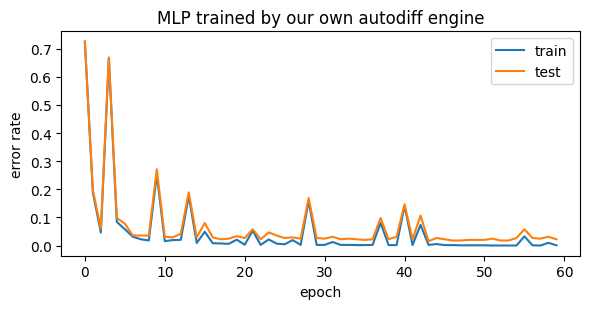

In [14]:
def train(hidden=128, lr=0.5, B=64, epochs=60, seed=0):
    rng = np.random.default_rng(seed)
    sizes = [n, hidden, k]
    Ws = [Tensor(rng.normal(0, np.sqrt(2.0 / a), (a, b)))
          for a, b in zip(sizes[:-1], sizes[1:])]

    def err(X, y):
        logits = mlp_forward(Tensor.make_const(X), *Ws).data
        return float((np.argmax(logits, 1) != y).mean())

    hist = []
    for _ in range(epochs):
        order = rng.permutation(m)
        for i in range(0, m, B):
            idx = order[i:i+B]
            Xb = Tensor.make_const(X_train[idx])
            Yb = Tensor.make_const(one_hot(y_train[idx], k))

            loss = softmax_loss(mlp_forward(Xb, *Ws), Yb)
            loss.backward()

            # Rebuild each parameter as a fresh leaf. Without this the
            # parameters would accumulate the whole training history.
            Ws = [Tensor(W.data - lr * W.grad.data) for W in Ws]
        hist.append((err(X_train, y_train), err(X_test, y_test)))
    return Ws, hist

Ws, hist = train()
print(f"train error {hist[-1][0]:.4f}   test error {hist[-1][1]:.4f}"
      f"   accuracy {1-hist[-1][1]:.4f}")

plt.figure(figsize=(6, 3.2))
plt.plot([h[0] for h in hist], label="train")
plt.plot([h[1] for h in hist], label="test")
plt.xlabel("epoch"); plt.ylabel("error rate"); plt.legend()
plt.title("MLP trained by our own autodiff engine")
plt.tight_layout(); plt.show()

Same architecture, same optimizer, same accuracy as the hand-derived version in lecture 4 — and
the difference is the point: **no gradient in this
notebook was derived by hand.** `softmax_loss` and `mlp_forward` describe only the forward
computation. Everything else came from composing the one-step rules in each `Op.gradient`.

Change the architecture and nothing about the gradient code changes. That is what the 44,000
lines of 2012 bought, and why it is worth roughly 150 lines today.

## Summary

- A `Value` is data plus provenance: `cached_data`, `op`, `inputs`, `requires_grad`. The computational graph *is* the object graph.
- Every op implements `compute` on arrays and `gradient` on graph nodes. That asymmetry is deliberate and is what buys gradient-of-gradient — verified here on $f(x)=x^3$.
- Construction and evaluation are separate: `make_from_op` records, `realize_cached_data` computes. Eager runs it now; lazy defers so the whole graph can be optimized at once.
- Reverse topological order is what makes the multiple-pathway sum correct without extra bookkeeping.
- Accumulating a tensor in a loop grows a graph, not a number. `detach` keeps the value and drops the history.

### Where this series goes next

The backend is still numpy. Later lectures replace `compute` with real hardware acceleration,
then build convolutions, normalisation, and transformers on top of this same interface — without
ever touching the autodiff engine again.